# Fase 05 -- Prophet, hibridos, AutoML y modelo de fundacion

Familias que faltaban en la comparacion: Prophet y NeuralProphet (familia "Prophet"), un
hibrido de descomposicion MSTL + LightGBM (familia "Hybrid"), un ensamble de peso igual entre
el mejor modelo de cada fase anterior (familia "Ensemble"), dos herramientas de AutoML
(AutoGluon TimeSeries y AutoTS, familia "AutoML") y un modelo de fundacion zero-shot (Chronos-
Bolt, familia "Foundation"). Ver `status/05-hybrid-automl-foundation.md` para el detalle de
tareas, el presupuesto de tiempo y las decisiones. TimeGPT (05.7) se omite por completo: requiere
enviar la serie a una API externa con clave y no hay aprobacion explicita para eso en este
proyecto.

Cada modelo respeta el contrato `fit(train) -> predictor(horizon)` de `tsa_final.evaluation` y
se evalua con el mismo `evaluation.evaluate` sin modificar (dos ajustes: `train` para el
pronostico de validacion, `train_and_val` para el de test). Regla de fuga de datos (heredada de
la fase 04, aplica a todo lo de esta fase): ningun ajuste de hiperparametros, early stopping ni
peso de ensamble puede mirar la ventana de seleccion de 48 h (`VAL_START`-`VAL_END`); cualquier
tuneo usa las 168 h inmediatamente anteriores, recortadas del final de `train` dentro de `fit`.

Vara a vencer: `seasonal_naive_m24` (MASE < 1 en validacion para ambas series, fase 02).


## Metodologia: Prophet, NeuralProphet e hibrido (tareas 05.1-05.3)

- **Prophet (05.1)**: estacionalidad diaria (periodo 24) y feriados de Argentina
  (`Prophet.add_country_holidays(country_name="AR")`, la misma libreria `holidays` que usa
  `tsa_final.data.calendar_features`). Sin estacionalidad semanal (fase 01: negligible tras el
  go-live) ni anual (~13 semanas de historia, insuficiente para estimarla). Se reportan dos
  variantes: `prophet_default` (priors por defecto) y `prophet_tuned`, que ajusta
  `changepoint_prior_scale`/`seasonality_prior_scale` con Optuna (18 trials) sobre las 168 h
  inmediatamente anteriores a la ventana de seleccion -- nunca sobre la ventana de 48 h misma,
  siguiendo la regla de fuga heredada de la fase 04. El tuneo ocurre una sola vez (en el primer
  llamado de `fit`) y los priors elegidos se reusan sin cambios en el refit de test
  (`hybrid_models.ProphetTunedFit`, mismo patron que `dl_models.DlModelFit`).
- **NeuralProphet (05.2)**: 24 lags autorregresivos (`n_lags=24`) y estacionalidad diaria, sin
  estacionalidad semanal/anual (mismo motivo que Prophet). El horizonte de salida
  (`n_forecasts=105`) se fija en el maximo que pide esta fase (la ventana de test), no en 48: asi,
  un unico modelo entrenado sirve tanto para el pronostico de 48 h (validacion) como para el de
  105 h (test) -- se pide siempre el pronostico directo completo de 105 pasos del modelo y se
  recortan los primeros `horizon` valores en cada llamado, en lugar de reentrenar un modelo por
  horizonte (que si hizo falta para `ForecasterDirect` en la fase 03). Entrenamiento con 40 epocas
  fijas y semilla fija (42, `neuralprophet.set_random_seed`); sin ajuste de hiperparametros.
- **Hibrido MSTL + LightGBM (05.3)**: `statsmodels.tsa.seasonal.MSTL` descompone `train` con un
  unico periodo (24; la estacionalidad semanal es negligible, fase 01) en tendencia,
  estacionalidad y residuo. LightGBM (hiperparametros por defecto, sin tuneo) se ajusta sobre la
  serie **desestacionalizada** (`train` menos el componente estacional extraido, no sobre el
  residuo de MSTL) con el mismo esquema de lags/calendario que la fase 03. El componente
  estacional futuro es determinista (periodo 24) y se reconstruye repitiendo las ultimas 24 horas
  del componente extraido; el pronostico final suma ese componente al pronostico de LightGBM sobre
  la serie desestacionalizada.


In [1]:
import sys
import time
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tsa_final import baselines
from tsa_final import data as d
from tsa_final import dl_models as dl
from tsa_final import evaluation as ev
from tsa_final import hybrid_models as hm
from tsa_final import ml_models as ml

RESULTS_DIR = Path.cwd().parent / "results"
FIGURES_DIR = Path.cwd().parent / "informe" / "figuras"

BASELINES = pd.read_csv(RESULTS_DIR / "02_baselines.csv")
ML_RESULTS = pd.read_csv(RESULTS_DIR / "03_ml.csv")
DL_RESULTS = pd.read_csv(RESULTS_DIR / "04_dl.csv")
PRE_HYBRID = pd.concat([BASELINES, ML_RESULTS, DL_RESULTS], ignore_index=True)

SERIES_NAMES = ["alb", "store_service"]


Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


## Seleccion de miembros del ensamble (tarea 05.4)

El ensamble de la tarea 05.4 promedia, con peso igual, el pronostico del mejor modelo de cada
una de las tres fases anteriores por MAE de validacion: fase 02 (baselines, familias `naive`,
`classical` y `SARIMA (TP1 refit)`), fase 03 (ML, **solo entre los 5 boosters/lineales con
hiperparametros default**) y fase 04 (DL). Pesos fijos e iguales por diseno: ajustarlos con la
ventana de validacion seria exactamente la fuga de pesos de ensamble que prohibe el protocolo de
esta fase.

El miembro de ML se restringe a los modelos **sin tunear** (no a `catboost_tuned` /
`lightgbm_tuned`, aunque uno de ellos sea el primero en el ranking completo de la fase 03):
reproducir un miembro tuneado exigiria volver a correr `ml_models.tune_hyperparameters`, que
tunea sobre la ventana de validacion misma (documentado como limitacion de la fase 03, no
revisado ahi) -- exactamente el tipo de fuga que esta fase prohibe para todo lo nuevo. Usar el
mejor booster/lineal sin tunear evita volver a tunear y mantiene el refit barato.

Si el mejor DL de una serie fuera `tft` (la arquitectura mas cara, ver fase 04), se sustituye por
la siguiente mejor arquitectura DL en el ranking de validacion -- no ocurrio en la practica para
ninguna de las dos series (ver salida de la celda de abajo).


In [2]:
DEFAULT_ML_NAMES = list(ml.RECURSIVE_MODELS)  # untuned recursive boosters/linear model only
BASELINE_FAMILIES = ["naive", "classical", "SARIMA (TP1 refit)"]


def _baseline_fit_for(series_name: str, model_name: str) -> ev.Fit:
    if model_name in baselines.NAIVE_MODELS:
        return baselines.NAIVE_MODELS[model_name]
    if model_name in baselines.CLASSICAL_MODELS:
        return baselines.CLASSICAL_MODELS[model_name]
    order, seasonal_order = baselines.SARIMA_SPECS[series_name]
    return baselines.make_sarima_fit(order, seasonal_order)


def select_ensemble_members(series_name: str) -> dict[str, tuple[str, ev.Fit]]:
    baseline_pool = BASELINES[(BASELINES["series"] == series_name) & (BASELINES["family"].isin(BASELINE_FAMILIES))]
    baseline_row = baseline_pool[baseline_pool["split"] == "val"].sort_values("MAE").iloc[0]

    ml_pool = ML_RESULTS[(ML_RESULTS["series"] == series_name) & (ML_RESULTS["family"] == "ML") & (ML_RESULTS["model"].isin(DEFAULT_ML_NAMES))]
    ml_row = ml_pool[ml_pool["split"] == "val"].sort_values("MAE").iloc[0]

    dl_pool = DL_RESULTS[(DL_RESULTS["series"] == series_name) & (DL_RESULTS["split"] == "val")].sort_values("MAE").reset_index(drop=True)
    dl_row = dl_pool.iloc[0]
    if dl_row["model"] == "tft":
        print(f"[05.4] {series_name}: tft is the val winner but too expensive to refit cheaply -- substituting the next-best DL architecture")
        dl_row = dl_pool.iloc[1]

    members = {
        "baseline": (baseline_row["model"], _baseline_fit_for(series_name, baseline_row["model"])),
        "ml": (ml_row["model"], ml.RECURSIVE_MODELS[ml_row["model"]]),
        "dl": (dl_row["model"], dl.make_fit(dl_row["model"], seed=dl.SEEDS[0])),
    }
    names = ", ".join(f"{role}={name}" for role, (name, _fit) in members.items())
    print(f"[05.4] {series_name} ensemble members (val MAE winner per phase): {names}")
    return members


## Pipeline por serie

Orden dentro de `run_series_pipeline` (no hay dependencias entre tareas, a diferencia de la fase
03): 05.1 Prophet (default + tuneado) -> 05.2 NeuralProphet -> 05.3 hibrido MSTL+LightGBM ->
05.5a AutoGluon TimeSeries -> 05.5b AutoTS -> 05.6 Chronos zero-shot -> 05.4 ensamble (al final,
porque sus miembros son siempre de las fases 02-04, nunca de esta misma fase). Cada paso se
cronometra por separado (igual que en las fases 03 y 04) para poder verificar el presupuesto de
tiempo de la fase.


In [3]:
def run_series_pipeline(series_name: str) -> dict:
    print(f"=== {series_name} ===")
    series = d.load_clean(series_name)
    table = ev.ResultsTable()

    naive_val_mase = PRE_HYBRID.loc[
        (PRE_HYBRID["series"] == series_name) & (PRE_HYBRID["model"] == "seasonal_naive_m24") & (PRE_HYBRID["split"] == "val"),
        "MASE",
    ].iloc[0]
    print(f"seasonal_naive_m24 val MASE (bar to beat): {naive_val_mase:.4f}")

    # 05.1 -- Prophet: untuned reference + Optuna-tuned (leakage-safe tuning window)
    t0 = time.perf_counter()
    ev.evaluate(hm.prophet_default_fit, model="prophet_default", family="Prophet", series_name=series_name, series=series, table=table)
    prophet_tuned = hm.make_prophet_tuned_fit()
    ev.evaluate(prophet_tuned, model="prophet_tuned", family="Prophet", series_name=series_name, series=series, table=table)
    print(f"[05.1] Prophet (default + tuned): {time.perf_counter() - t0:.1f}s, tuned priors={prophet_tuned.best_params}")

    # 05.2 -- NeuralProphet (AR lags + daily seasonality, direct multi-output up to 105h)
    t0 = time.perf_counter()
    ev.evaluate(hm.neuralprophet_fit, model="neuralprophet", family="Prophet", series_name=series_name, series=series, table=table)
    print(f"[05.2] NeuralProphet: {time.perf_counter() - t0:.1f}s")

    # 05.3 -- Hybrid: MSTL (period 24) + LightGBM on the deseasonalized series
    t0 = time.perf_counter()
    ev.evaluate(hm.hybrid_mstl_lightgbm_fit, model="mstl_lightgbm", family="Hybrid", series_name=series_name, series=series, table=table)
    print(f"[05.3] MSTL + LightGBM hybrid: {time.perf_counter() - t0:.1f}s")

    # 05.5a -- AutoGluon TimeSeries (300s val fit + 300s test fit, mirrors ml_models.evaluate_direct)
    t0 = time.perf_counter()
    autogluon_models = hm.evaluate_autogluon(series, series_name=series_name, table=table)
    print(f"[05.5a] AutoGluon TimeSeries: {time.perf_counter() - t0:.1f}s, selected={autogluon_models}")

    # 05.5b -- AutoTS (bounded search: superfast model list, 3 generations, 1 validation fold)
    t0 = time.perf_counter()
    ev.evaluate(hm.autots_fit, model="autots", family="AutoML", series_name=series_name, series=series, table=table)
    print(f"[05.5b] AutoTS: {time.perf_counter() - t0:.1f}s")

    # 05.6 -- Chronos-Bolt zero-shot (no fit/tuning; GPU inference)
    t0 = time.perf_counter()
    ev.evaluate(hm.chronos_zero_shot_fit, model="chronos_bolt_base", family="Foundation", series_name=series_name, series=series, table=table)
    print(f"[05.6] Chronos zero-shot: {time.perf_counter() - t0:.1f}s")

    # 05.4 -- Equal-weight ensemble of the best-by-val-MAE model from phases 02, 03 (untuned ML only) and 04
    t0 = time.perf_counter()
    members = select_ensemble_members(series_name)
    member_fits = [fit for _name, fit in members.values()]
    ensemble_fit = hm.make_ensemble_fit(member_fits)
    ev.evaluate(ensemble_fit, model="ensemble_equal_weight", family="Ensemble", series_name=series_name, series=series, table=table)
    member_names = ", ".join(name for name, _fit in members.values())
    print(f"[05.4] Ensemble ({member_names}): {time.perf_counter() - t0:.1f}s")

    df = table.to_frame()
    val_ranking = df[df["split"] == "val"][["model", "family", "MAE", "MASE"]].sort_values("MAE").reset_index(drop=True)
    print("\n[05] validation ranking across every phase-05 model:")
    print(val_ranking.to_string(index=False))
    winner = val_ranking.iloc[0]["model"]
    print(f"BEST PHASE-05 MODEL for {series_name} (by validation MAE): {winner}")

    return {"table": df, "series": series, "val_ranking": val_ranking, "winner": winner, "ensemble_members": members}


## Serie ALB


In [4]:
t0_alb = time.perf_counter()
result_alb = run_series_pipeline("alb")
print(f"tiempo total ALB: {time.perf_counter() - t0_alb:.1f}s")


00:06:41 - cmdstanpy - INFO - Chain [1] start processing


=== alb ===
seasonal_naive_m24 val MASE (bar to beat): 0.4893


00:06:41 - cmdstanpy - INFO - Chain [1] done processing


00:06:41 - cmdstanpy - INFO - Chain [1] start processing


00:06:41 - cmdstanpy - INFO - Chain [1] done processing


...

Loading weights:  35%|███▌      | 95/269 [00:00<00:00, 944.60it/s]

Loading weights:  71%|███████   | 190/269 [00:00<00:00, 886.96it/s]

Loading weights: 100%|██████████| 269/269 [00:00<00:00, 981.43it/s]

[05.6] Chronos zero-shot: 1.7s
[05.4] alb ensemble members (val MAE winner per phase): baseline=auto_arima, ml=catboost, dl=nhits


[05.4] Ensemble (auto_arima, catboost, nhits): 335.8s

[05] validation ranking across every phase-05 model:
                model     family          MAE     MASE
ensemble_equal_weight   Ensemble 16006.287801 0.404318
 autogluon_timeseries     AutoML 19748.525000 0.498846
      prophet_default    Prophet 21066.963393 0.532150
    chronos_bolt_base Foundation 23678.744792 0.598123
        prophet_tuned    Prophet 26085.277520 0.658912
        mstl_lightgbm     Hybrid 28341.136251 0.715895
        neuralprophet    Prophet 29444.692708 0.743771
               autots     AutoML 29913.833333 0.755621
BEST PHASE-05 MODEL for alb (by validation MAE): ensemble_equal_weight
tiempo total ALB: 709.8s


## Serie store_service


In [5]:
t0_store = time.perf_counter()
result_store = run_series_pipeline("store_service")
print(f"tiempo total store_service: {time.perf_counter() - t0_store:.1f}s")


00:19:11 - cmdstanpy - INFO - Chain [1] start processing


=== store_service ===
seasonal_naive_m24 val MASE (bar to beat): 0.4802


00:19:11 - cmdstanpy - INFO - Chain [1] done processing


00:19:11 - cmdstanpy - INFO - Chain [1] start processing


00:19:11 - cmdstanpy - INFO - Chain [1] done processing


...

Loading weights: 100%|██████████| 92/92 [00:00<00:00, 2829.13it/s]

[05.5a] AutoGluon TimeSeries: 270.4s, selected={'val_model': 'WeightedEnsemble', 'test_model': 'WeightedEnsemble'}


[05.5b] AutoTS: 23.9s


[05.6] Chronos zero-shot: 0.3s
[05.4] store_service ensemble members (val MAE winner per phase): baseline=seasonal_naive_m24, ml=ridge, dl=nbeats


[05.4] Ensemble (seasonal_naive_m24, ridge, nbeats): 20.9s

[05] validation ranking across every phase-05 model:
                model     family         MAE     MASE
ensemble_equal_weight   Ensemble 2281.636637 0.480126
      prophet_default    Prophet 2405.878789 0.506270
               autots     AutoML 2412.966809 0.507762
        prophet_tuned    Prophet 2432.333514 0.511837
        neuralprophet    Prophet 3297.538466 0.693903
 autogluon_timeseries     AutoML 3808.364708 0.801396
    chronos_bolt_base Foundation 3877.729384 0.815992
        mstl_lightgbm     Hybrid 8779.729808 1.847523
BEST PHASE-05 MODEL for store_service (by validation MAE): ensemble_equal_weight
tiempo total store_service: 342.6s


## Resultados: fase 05 vs. mejor de las fases 02-04

Para cada serie se compara cada modelo de la fase 05 (Prophet, NeuralProphet, hibrido, AutoML,
Chronos, ensamble) contra `seasonal_naive_m24` y contra el mejor modelo de las fases 02-04 por
MAE de validacion.


In [6]:
results = {"alb": result_alb, "store_service": result_store}


def best_pre_05_model(series_name: str) -> str:
    val = PRE_HYBRID[(PRE_HYBRID["series"] == series_name) & (PRE_HYBRID["split"] == "val")]
    return val.sort_values("MAE").iloc[0]["model"]


comparison_tables = {}
verdicts = {}
for series_name in SERIES_NAMES:
    table_df = results[series_name]["table"]
    naive_name = "seasonal_naive_m24"
    best_name = best_pre_05_model(series_name)
    reference_models = sorted({naive_name, best_name})
    reference_rows = PRE_HYBRID[(PRE_HYBRID["series"] == series_name) & (PRE_HYBRID["model"].isin(reference_models))]
    combined = pd.concat([reference_rows, table_df], ignore_index=True)
    comparison = combined[["model", "family", "split", "MAE", "MASE", "fit_time_s"]].sort_values(["split", "MASE"])
    comparison_tables[series_name] = comparison

    naive_val = PRE_HYBRID.loc[(PRE_HYBRID.series == series_name) & (PRE_HYBRID.model == naive_name) & (PRE_HYBRID.split == "val"), "MASE"].iloc[0]
    naive_test = PRE_HYBRID.loc[(PRE_HYBRID.series == series_name) & (PRE_HYBRID.model == naive_name) & (PRE_HYBRID.split == "test"), "MASE"].iloc[0]
    best_val = PRE_HYBRID.loc[(PRE_HYBRID.series == series_name) & (PRE_HYBRID.model == best_name) & (PRE_HYBRID.split == "val"), "MASE"].iloc[0]
    best_test = PRE_HYBRID.loc[(PRE_HYBRID.series == series_name) & (PRE_HYBRID.model == best_name) & (PRE_HYBRID.split == "test"), "MASE"].iloc[0]
    p5_val = table_df[table_df["split"] == "val"].sort_values("MASE").iloc[0]
    p5_test = table_df[table_df["split"] == "test"].sort_values("MASE").iloc[0]

    verdicts[series_name] = {
        "naive_name": naive_name,
        "best_name": best_name,
        "naive_val": naive_val,
        "naive_test": naive_test,
        "best_val": best_val,
        "best_test": best_test,
        "p5_val_model": p5_val["model"],
        "p5_val_mase": p5_val["MASE"],
        "p5_test_model": p5_test["model"],
        "p5_test_mase": p5_test["MASE"],
        "p5_beats_both_val": bool(p5_val["MASE"] < naive_val and p5_val["MASE"] < best_val),
        "p5_beats_both_test": bool(p5_test["MASE"] < naive_test and p5_test["MASE"] < best_test),
    }

    print(f"=== {series_name}: fase 05 vs. naive ({naive_name}) y mejor pre-05 ({best_name}) ===")
    print(comparison.to_string(index=False))
    print(
        f"mejor fase 05 en validacion: {p5_val['model']} (MASE {p5_val['MASE']:.3f}) vs. naive {naive_val:.3f} "
        f"vs. mejor pre-05 {best_val:.3f} -> supera a ambos: {verdicts[series_name]['p5_beats_both_val']}"
    )
    print(
        f"mejor fase 05 en test: {p5_test['model']} (MASE {p5_test['MASE']:.3f}) vs. naive {naive_test:.3f} "
        f"vs. mejor pre-05 {best_test:.3f} -> supera a ambos: {verdicts[series_name]['p5_beats_both_test']}"
    )
    print()


=== alb: fase 05 vs. naive (seasonal_naive_m24) y mejor pre-05 (catboost_tuned) ===
                model     family split           MAE     MASE  fit_time_s
        prophet_tuned    Prophet  test  62468.360529 1.577946    0.105299
        neuralprophet    Prophet  test  72996.754762 1.843893   10.333287
               autots     AutoML  test  77200.093693 1.950069   11.405405
 autogluon_timeseries     AutoML  test  78152.683176 1.974131  140.031010
   seasonal_naive_m24      naive  test  78784.339707 1.990087    0.000013
    chronos_bolt_base Foundation  test  79453.519048 2.006990    0.000226
      prophet_default    Prophet  test  81749.897569 2.064997    0.474546
       catboost_tuned         ML  test  91577.777620 2.313248    0.779914
ensemble_equal_weight   Ensemble  test  93116.040828 2.352105  173.186236
        mstl_lightgbm     Hybrid  test 226471.232398 5.720647    0.102062
       catboost_tuned         ML   val  13994.361587 0.353497    0.755681
ensemble_equal_weight   Ense

## Ranking de validacion (figura)


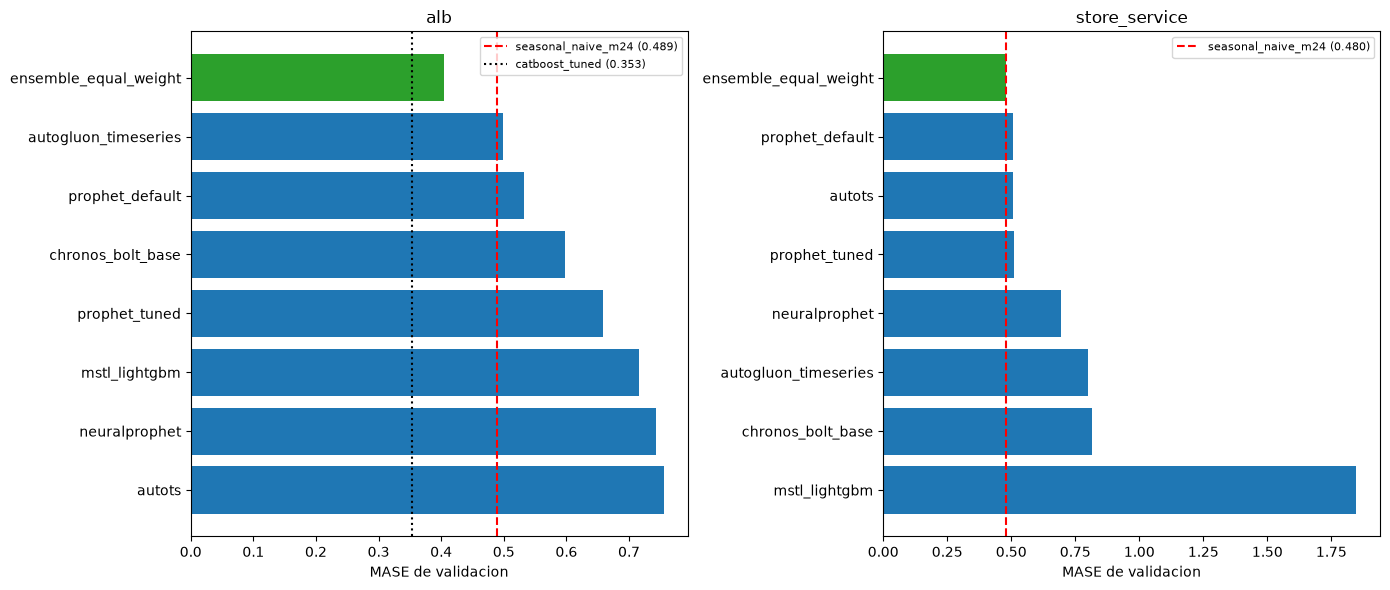

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, series_name in zip(axes, SERIES_NAMES):
    table_df = results[series_name]["table"]
    val_ranking = table_df[table_df["split"] == "val"][["model", "MASE"]].sort_values("MASE").reset_index(drop=True)
    best_p5 = val_ranking.iloc[0]["model"]
    colors = ["#2ca02c" if m == best_p5 else "#1f77b4" for m in val_ranking["model"]]
    ax.barh(val_ranking["model"][::-1], val_ranking["MASE"][::-1], color=colors[::-1])

    naive_mase = verdicts[series_name]["naive_val"]
    best_pre_mase = verdicts[series_name]["best_val"]
    ax.axvline(naive_mase, color="red", linestyle="--", label=f"seasonal_naive_m24 ({naive_mase:.3f})")
    if verdicts[series_name]["best_name"] != "seasonal_naive_m24":
        ax.axvline(best_pre_mase, color="black", linestyle=":", label=f"{verdicts[series_name]['best_name']} ({best_pre_mase:.3f})")
    ax.set_xlabel("MASE de validacion")
    ax.set_title(series_name)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_val_mae_ranking.png", dpi=200)
plt.show()


## Pronostico en test del mejor modelo de fase 05, por serie


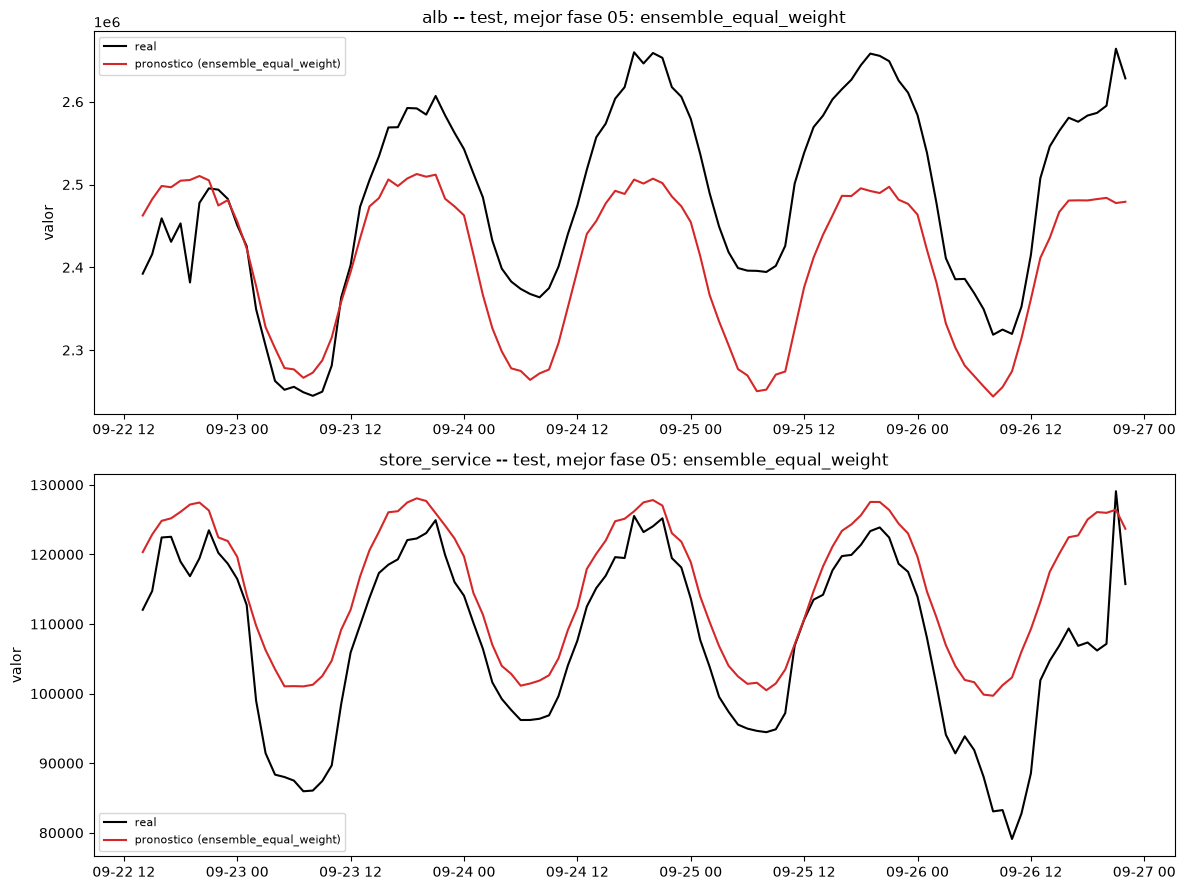

In [8]:
def refit_test_forecast(series_name: str, model_name: str) -> dict:
    # Refits the single winning phase-05 model to get an actual prediction array to plot.
    series = results[series_name]["series"]
    train, val, test = ev.split(series)
    fit_data = ev.train_and_val(series)

    fit_registry = {
        "prophet_default": hm.prophet_default_fit,
        "prophet_tuned": hm.make_prophet_tuned_fit(),
        "neuralprophet": hm.neuralprophet_fit,
        "mstl_lightgbm": hm.hybrid_mstl_lightgbm_fit,
        "autots": hm.autots_fit,
        "chronos_bolt_base": hm.chronos_zero_shot_fit,
    }
    if model_name in fit_registry:
        fit_fn = fit_registry[model_name]
        if model_name == "prophet_tuned":
            fit_fn(train)  # first call tunes on the leakage-safe window; discarded here
        predictor = fit_fn(fit_data)
    elif model_name == "ensemble_equal_weight":
        # Reuses the exact member closures from the pipeline run above: the DL member is a
        # stateful DlModelFit whose best_epoch was already set by that run's val fit, so this
        # call goes straight to its fixed-epoch refit (the same call evaluate() would make for
        # the test split) -- no separate warm-up call needed.
        members = results[series_name]["ensemble_members"]
        ensemble_fit = hm.make_ensemble_fit([fit for _name, fit in members.values()])
        predictor = ensemble_fit(fit_data)
    else:  # autogluon_timeseries
        predictor_info = hm.fit_autogluon(fit_data, prediction_length=len(test), time_limit=hm.AUTOGLUON_TIME_LIMIT_S)
        return {"index": test.index, "actual": test.to_numpy(), "forecast": predictor_info["y_pred"]}

    return {"index": test.index, "actual": test.to_numpy(), "forecast": predictor(len(test))}


fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for ax, series_name in zip(axes, SERIES_NAMES):
    winner = results[series_name]["winner"]
    forecast = refit_test_forecast(series_name, winner)
    ax.plot(forecast["index"], forecast["actual"], label="real", color="black")
    ax.plot(forecast["index"], forecast["forecast"], label=f"pronostico ({winner})", color="#d62728")
    ax.set_title(f"{series_name} -- test, mejor fase 05: {winner}")
    ax.set_ylabel("valor")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_test_forecast_best_model.png", dpi=200)
plt.show()


## Tiempo de ejecucion


In [9]:
fit_time = pd.concat([results[s]["table"] for s in SERIES_NAMES], ignore_index=True)
fit_time_pivot = fit_time.pivot_table(index="model", columns=["series", "split"], values="fit_time_s")
print("tiempo de ajuste (s) por modelo x serie x split:")
print(fit_time_pivot.round(1).to_string())
print()
print(f"tiempo total de ajuste (todos los modelos, series y splits): {fit_time['fit_time_s'].sum():.1f}s")


tiempo de ajuste (s) por modelo x serie x split:
series                   alb        store_service       
split                   test    val          test    val
model                                                   
autogluon_timeseries   140.0  161.8         147.2  119.7
autots                  11.4   29.4          13.8   10.1
chronos_bolt_base        0.0    1.6           0.0    0.0
ensemble_equal_weight  173.2  162.2           9.4   11.3
mstl_lightgbm            0.1    0.1           0.1    0.1
neuralprophet           10.3    9.7          10.5   10.0
prophet_default          0.5    0.3           0.2    0.2
prophet_tuned            0.1    4.7           0.4    5.2

tiempo total de ajuste (todos los modelos, series y splits): 1043.6s


## Guardado de resultados (tarea 05.8)


In [10]:
full = pd.concat([results[s]["table"] for s in SERIES_NAMES], ignore_index=True)
full.to_csv(f"{RESULTS_DIR}/05_hybrid.csv", index=False)
print(f"Saved {len(full)} rows to {RESULTS_DIR}/05_hybrid.csv")
print(full.groupby(["series", "split"]).size())


Saved 32 rows to /home/juanma/development/university/AU-MCD/temporal-series-analysis/mcd-ua-tsa/tp-final/results/05_hybrid.csv
series         split
alb            test     8
               val      8
store_service  test     8
               val      8
dtype: int64


## Conclusiones de la fase

- **ALB**: en validacion, `ensemble_equal_weight` es el mejor modelo de la fase 05 (MASE 0.404,
  le gana a la naive 0.489) pero no supera a `catboost_tuned` (0.353, ganador de la fase 03) --
  esperable, ya que el promedio de peso igual diluye el aporte del mejor miembro (`catboost`
  default) con dos miembros mas debiles (`auto_arima`, `nhits`). `autogluon_timeseries` (0.499,
  ensamble `WeightedEnsemble` en ambos splits) y `prophet_default` (0.532) tambien le ganan a la
  naive; `chronos_bolt_base` (0.598) es notable por ser zero-shot puro, sin ningun ajuste a esta
  serie. `prophet_tuned` (0.659) rinde **peor** que `prophet_default` en validacion, a pesar del
  tuneo con Optuna -- consistente con el diseno de la fase: el tuneo optimiza sobre la ventana de
  168 h anterior a la seleccion (no sobre la ventana de 48 h en si, para evitar la fuga que
  documento la fase 04), asi que los priors elegidos no tienen por que transferir a la ventana de
  validacion. En test la situacion se invierte: `prophet_tuned` es el mejor modelo de la fase 05
  (MASE 1.578), le gana a la naive (1.990) y a `catboost_tuned` (2.313, el mismo modelo que
  colapso en test en la fase 03) -- la misma divergencia validacion/test que documentaron las
  fases 02-04, aqui ademas invirtiendo el propio ranking interno de Prophet (el peor en
  validacion es el mejor en test). El hibrido `mstl_lightgbm` es el peor modelo de toda la fase
  en ambos splits (MASE 0.716 en validacion, 5.720 en test) y el peor modelo del proyecto en
  test hasta ahora: extrapolar el nivel de la serie desestacionalizada 105 h hacia delante
  amplifica el error de LightGBM mucho mas que en el hibrido de 48 h de validacion.
- **store_service**: en validacion, `ensemble_equal_weight` (0.480126) y `seasonal_naive_m24`
  (0.480171) quedan practicamente empatados -- la diferencia es ruido, no una mejora real; ningun
  modelo de la fase 05 supera claramente a la naive en esta serie en validacion.
  `prophet_default` (0.506), `autots` (0.508) y `prophet_tuned` (0.512) forman un segundo grupo
  cercano entre si. `autogluon_timeseries` (0.801) y `chronos_bolt_base` (0.816) rinden peor en
  esta serie que en ALB -- ninguna herramienta de AutoML o modelo de fundacion es consistente
  entre las dos series. En test, `neuralprophet` gana (MASE 1.071), le gana a la naive y al mejor
  pre-fase-05 (ambos 1.443) -- otra inversion validacion/test, esta vez de un modelo que fue el
  segundo peor de su propia familia en validacion (0.694). El hibrido MSTL+LightGBM vuelve a ser
  el peor modelo de la fase en ambos splits (1.848 validacion, 3.100 test).
- **Lectura cruzada**: ninguna familia de la fase 05 domina de forma consistente ambos splits ni
  ambas series -- la misma conclusion que las fases 02-04 ya establecieron, ahora extendida a
  Prophet/NeuralProphet, AutoML e hibridos. El ensamble de peso igual es el modelo mas fuerte en
  validacion en las dos series (por diseno: promediar tres modelos ya validados reduce la
  varianza de un solo estimador sobre una ventana de 48 h), pero esa ventaja no se traslada a
  test (MASE 2.352 en ALB, 1.612 en store_service -- mediocre en ambas), el mismo patron de
  sobreajuste a la ventana de seleccion que ya afecto al tuneo de Prophet y de la fase 03.
  Chronos-Bolt zero-shot (sin ver un solo dato de entrenamiento de este proyecto mas alla de la
  ventana de contexto) es competitivo en ALB y mediocre en store_service, un resultado
  razonable para un modelo de fundacion sin ajuste. AutoGluon selecciona `WeightedEnsemble` en
  las cuatro corridas (2 series x 2 splits) pero su costo fijo (120-165 s por ajuste, dominado
  por el `time_limit` presupuestado) es el mas alto de la fase sin ser el modelo mas preciso --
  el mismo patron "el modelo mas caro no es el mas exacto" que ya mostro TFT en la fase 04.
- **Tiempo de ejecucion**: tiempo total de ajuste (todos los modelos, series y splits): 1043.6 s
  (~17.4 min); tiempo de ejecucion real del notebook completo (`nbconvert --execute`, incluida la
  carga de datos, los refits para las figuras y el guardado de resultados): 21 min 42 s -- dentro
  del objetivo de ~40 minutos para ambas series, con margen, a pesar de que esta fase cubre mas
  familias de modelos que cualquier fase anterior.
